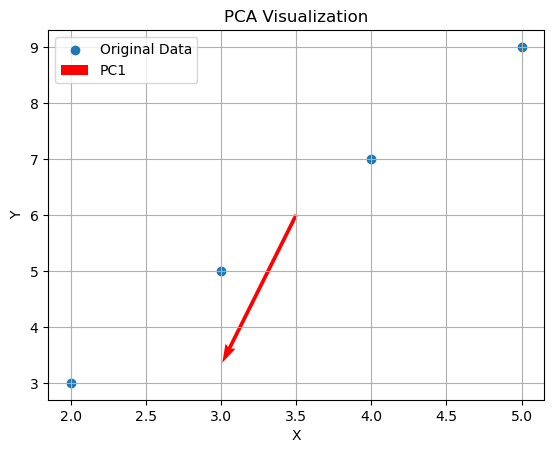

Original Data:
 [[2 3]
 [3 5]
 [4 7]
 [5 9]]

Centered Data:
 [[-1.5 -3. ]
 [-0.5 -1. ]
 [ 0.5  1. ]
 [ 1.5  3. ]]

Covariance Matrix:
 [[1.66666667 3.33333333]
 [3.33333333 6.66666667]]

Eigenvalues:
 [0.         8.33333333]

Principal Component:
 [[-0.4472136 ]
 [-0.89442719]]

Reduced Data:
 [[ 3.35410197]
 [ 1.11803399]
 [-1.11803399]
 [-3.35410197]]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
X=np.array([
    [2,3],[3,5],[4,7],[5,9]
])
mean=np.mean(X,axis=0)
X_centered=X-mean
cov_matrix=np.cov(X_centered,rowvar=False)
eigenvalues,eigenvectors=np.linalg.eig(cov_matrix)
sortedIndex=np.argsort(eigenvalues)[::-1]
eigenvectors=eigenvectors[:,sortedIndex]
w=eigenvectors[:,:1]
X_pca=X_centered.dot(w)

plt.scatter(X[:,0], X[:,1], label="Original Data")
origin = mean
pc1 = w[:,0]
plt.quiver(origin[0], origin[1], pc1[0], pc1[1],
           scale=3, color='red', label="PC1")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA Visualization")
plt.legend()
plt.grid()
plt.show()

print("Original Data:\n", X)
print("\nCentered Data:\n", X_centered)
print("\nCovariance Matrix:\n", cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nPrincipal Component:\n", w)
print("\nReduced Data:\n", X_pca)


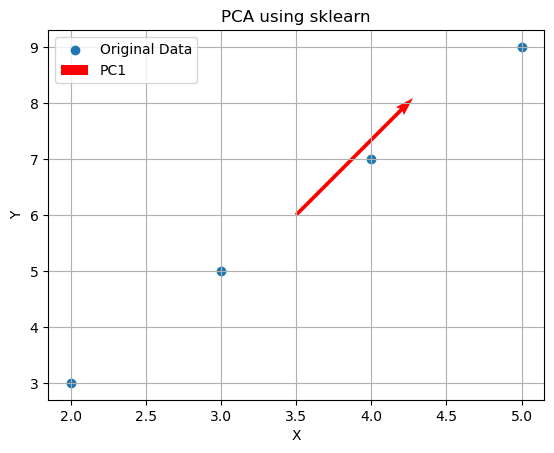

Original Data:
 [[2 3]
 [3 5]
 [4 7]
 [5 9]]

Scaled Data:
 [[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]

Principal Component (direction):
 [[0.70710678 0.70710678]]

Explained Variance Ratio:
 [1.]

Reduced Data:
 [[-1.8973666 ]
 [-0.63245553]
 [ 0.63245553]
 [ 1.8973666 ]]


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
pca=PCA(n_components=1)
X_pca=pca.fit_transform(X_scaled)

plt.scatter(X[:,0], X[:,1], label="Original Data")
mean = np.mean(X, axis=0)
pc1 = pca.components_[0]
plt.quiver(mean[0], mean[1],
           pc1[0], pc1[1],
           scale=3, color='red', label="PC1")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA using sklearn")
plt.legend()
plt.grid()
plt.show()

print("Original Data:\n", X)
print("\nScaled Data:\n", X_scaled)
print("\nPrincipal Component (direction):\n", pca.components_)
print("\nExplained Variance Ratio:\n", pca.explained_variance_ratio_)
print("\nReduced Data:\n", X_pca)

In [19]:
import numpy as np
x=np.array([1,2,3,4,5])
y=np.array([2,4,5,4,5])
x_mean=np.mean(x)
y_mean=np.mean(y)
numerator=np.sum((x-x_mean)*(y-y_mean))
denomenator=np.sum((x-x_mean)**2)
a1=numerator/denomenator
a0=y_mean-a1*x_mean
print("Slope (a1):", a1)
print("Intercept (a0):", a0)
print(f"Regression Equation: y = {a0:.2f} + {a1:.2f}x")
x_new = 6
y_pred = a0 + a1 * x_new
print(f"Prediction for x = {x_new}:", y_pred)

Slope (a1): 0.6
Intercept (a0): 2.2
Regression Equation: y = 2.20 + 0.60x
Prediction for x = 6: 5.8


Slope (a1): 0.6000000000000002
Intercept (a0): 2.1999999999999993

--- Validation Metrics ---
MSE: 0.4799999999999998
RMSE: 0.6928203230275508
MAE: 0.6399999999999999
R² Score: 0.6000000000000001

Prediction for x = 6: 5.800000000000001


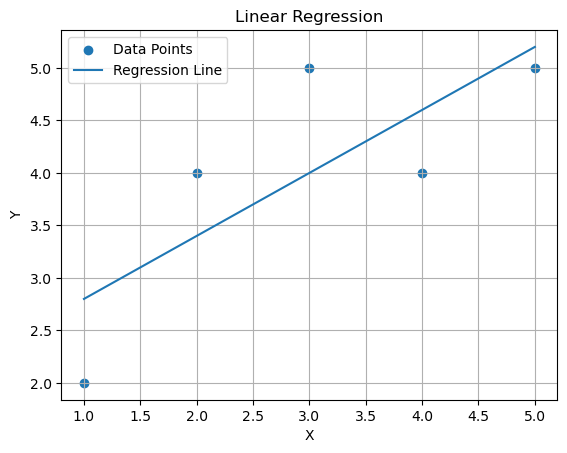

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([2,4,5,4,5])
model = LinearRegression()
model.fit(x, y)
print("Slope (a1):", model.coef_[0])
print("Intercept (a0):", model.intercept_)

y_pred = model.predict(x)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n--- Validation Metrics ---")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)
x_new = np.array([[6]])
y_new_pred = model.predict(x_new)
print("\nPrediction for x = 6:", y_new_pred[0])

plt.scatter(x, y, label="Data Points")
plt.plot(x, y_pred, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.grid()
plt.show()

Intercept (a0): 0.0
Coefficients (a1, a2): [1.33333333 0.33333333]

--- Validation Metrics ---
MSE: 6.7053176943786e-31
RMSE: 8.188600426433446e-16
MAE: 4.440892098500626e-16
R² Score: 1.0

Prediction for [6,5]: 9.666666666666668


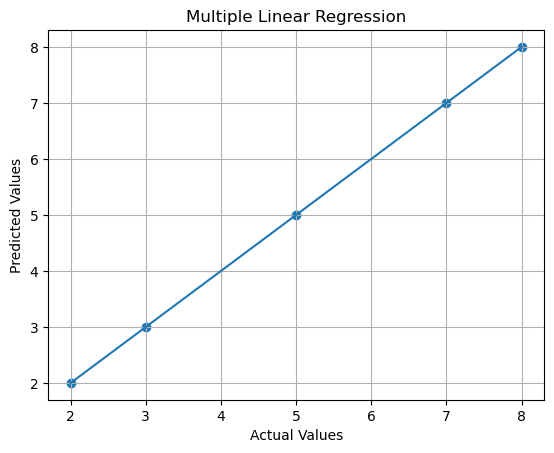

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],[2, 1],[3, 3],[4, 5],[5, 4]
])
y = np.array([2, 3, 5, 7, 8])
model = LinearRegression()
model.fit(X, y)
print("Intercept (a0):", model.intercept_)
print("Coefficients (a1, a2):", model.coef_)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("\n--- Validation Metrics ---")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

x_new = np.array([[6, 5]])
y_new = model.predict(x_new)
print("\nPrediction for [6,5]:", y_new[0])

plt.scatter(y, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")
plt.plot([min(y), max(y)], [min(y), max(y)])

plt.grid()
plt.show()

Intercept (a0): 8.881784197001252e-15
Coefficients: [ 0.00000000e+00 -1.21858361e-14  1.00000000e+00]

--- Validation ---
MSE: 5.029974346915477e-29
RMSE: 7.092231205280519e-15
R²: 1.0

Prediction for x = 6: 36.000000000000036


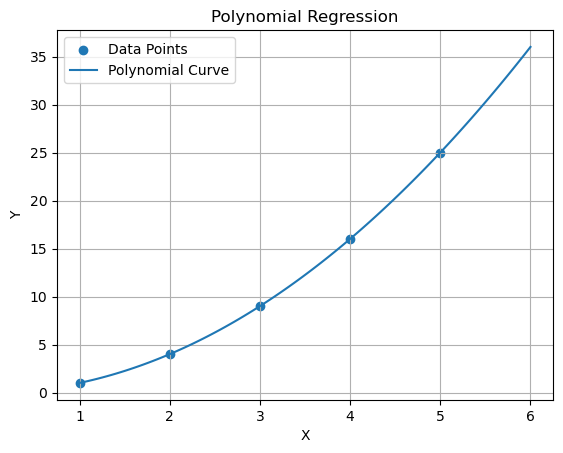

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([1,4,9,16,25])
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)
print("Intercept (a0):", model.intercept_)
print("Coefficients:", model.coef_)

print("\n--- Validation ---")
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

x_new = np.array([[6]])
x_new_poly = poly.transform(x_new)
y_new = model.predict(x_new_poly)
print("\nPrediction for x = 6:", y_new[0])

x_range = np.linspace(1, 6, 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
y_range = model.predict(x_range_poly)

plt.scatter(x, y, label="Data Points")
plt.plot(x_range, y_range, label="Polynomial Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.grid()
plt.show()

Coefficient (a1): 1.1206952510393664
Intercept (a0): -3.9223038967769632


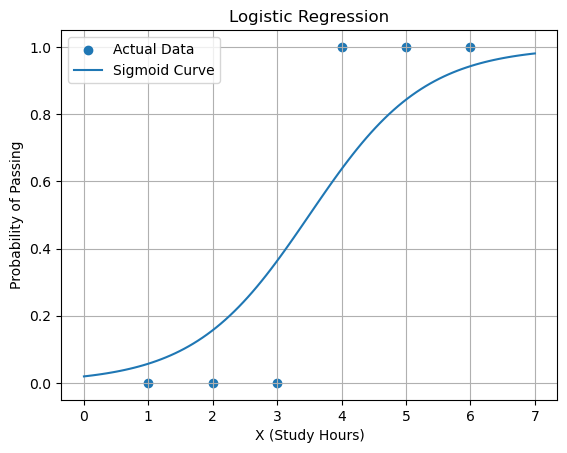

In [33]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([0,0,0,1,1,1])
model = LogisticRegression()
model.fit(X, y)

x_test = np.linspace(0,7,100).reshape(-1,1)
y_prob = model.predict_proba(x_test)[:,1]
print("Coefficient (a1):", model.coef_[0][0])
print("Intercept (a0):", model.intercept_[0])

plt.scatter(X, y, label="Actual Data")
plt.plot(x_test, y_prob, label="Sigmoid Curve")
plt.xlabel("X (Study Hours)")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")
plt.legend()
plt.grid()
plt.show()